In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## Load Database

In [2]:
from pathlib import Path
DB_PATH = Path.cwd().parent / "database" / "car_sales.parquet"

# Read database
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
df = pd.read_parquet(DB_PATH)
df.head()

,car_id,date,day,month,year,customer_name,gender,dealer_name,company,model,engine,transmission,color,dealer_no_,body_style,phone,dealer_region,price,income_customer,quantity,discount,gross_sales,discount_amount,sales,cost,total_cost,profit,profit_margin
0,C_CND_000001,2022-01-02,2,1,2022,Geraldine,Male,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,06457-3834,SUV,8264678,Middletown,"467,740,000.00","242,865,000.00",1,0.05,"467,740,000.00","23,387,000.00","444,353,000.00","347,588,502.33","347,588,502.33","96,764,497.67",21.78
1,C_CND_000002,2022-01-02,2,1,2022,Gia,Male,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,60504-7114,SUV,6848189,Aurora,"341,810,000.00","26,625,200,000.00",5,0.10,"1,709,050,000.00","170,905,000.00","1,538,145,000.00","281,435,978.53","1,407,179,892.65","130,965,107.35",8.51
2,C_CND_000003,2022-01-02,2,1,2022,Gianna,Male,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,38701-8047,Passenger,7298798,Greenville,"566,685,000.00","18,619,650,000.00",2,0.02,"1,133,370,000.00","22,667,400.00","1,110,702,600.00","433,036,322.96","866,072,645.92","244,629,954.08",22.02
3,C_CND_000004,2022-01-02,2,1,2022,Giselle,Male,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,99301-3882,SUV,6257557,Pasco,"251,860,000.00","242,865,000.00",1,0.50,"251,860,000.00","125,930,000.00","125,930,000.00","190,288,699.80","190,288,699.80","-64,358,699.80",-51.11
4,C_CND_000005,2022-01-02,2,1,2022,Grace,Male,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,53546-9427,Hatchback,7081483,Janesville,"440,755,000.00","26,355,350,000.00",4,0.10,"1,763,020,000.00","176,302,000.00","1,586,718,000.00","371,011,737.64","1,484,046,950.56","102,671,049.44",6.47


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23905 entries, 0 to 23904
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   car_id           23905 non-null  object 
 1   date             23905 non-null  object 
 2   day              23905 non-null  int32  
 3   month            23905 non-null  int32  
 4   year             23905 non-null  int32  
 5   customer_name    23905 non-null  object 
 6   gender           23905 non-null  object 
 7   dealer_name      23905 non-null  object 
 8   company          23905 non-null  object 
 9   model            23905 non-null  object 
 10  engine           23905 non-null  object 
 11  transmission     23905 non-null  object 
 12  color            23905 non-null  object 
 13  dealer_no_       23905 non-null  object 
 14  body_style       23905 non-null  object 
 15  phone            23905 non-null  int64  
 16  dealer_region    23905 non-null  object 
 17  price       

## Feature engineering

In [4]:
# Create column feature day_of_week, is_weekend, is_workday
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['is_workday'] = df['day_of_week'].apply(lambda x: 1 if x < 5 else 0)

In [5]:
# Build Season feature to define the season of the year based on the month
def season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"
    
df["season"] = df["month"].apply(season)

In [6]:
# Adjust date into dividen specific periods
df["quarter"] = df["date"].dt.quarter
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

In [7]:
# Build feature price_band as arrangement of price into 4 bands
df["price_band"] = pd.qcut(
    df["price"], q=5, labels=[
        "Budget","Economy", "Mid", "Premium", "Luxury"
    ]
)

In [8]:
# Create a feature of discount_level
df['discount_level'] = pd.cut(
    df['discount'], bins=[0,0.05,0.1,0.15,1],
    labels=[
        "Low",
        "Medium",
        "High",
        "Extreme"
    ]
)

# Create feature of weekend only discount by multiplying is_weekend and discount
df['weekend_discount'] = (df['is_weekend'] * df['discount'])

In [9]:
df.head(2)

,car_id,date,day,month,year,customer_name,gender,dealer_name,company,model,engine,transmission,color,dealer_no_,body_style,phone,dealer_region,price,income_customer,quantity,discount,gross_sales,discount_amount,sales,cost,total_cost,profit,profit_margin,day_of_week,is_weekend,is_workday,season,quarter,week_of_year,price_band,discount_level,weekend_discount
0,C_CND_000001,2022-01-02,2,1,2022,Geraldine,Male,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,06457-3834,SUV,8264678,Middletown,"467,740,000.00","242,865,000.00",1,0.05,"467,740,000.00","23,387,000.00","444,353,000.00","347,588,502.33","347,588,502.33","96,764,497.67",21.78,6,1,0,Winter,1,52,Mid,Low,0.05
1,C_CND_000002,2022-01-02,2,1,2022,Gia,Male,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,60504-7114,SUV,6848189,Aurora,"341,810,000.00","26,625,200,000.00",5,0.10,"1,709,050,000.00","170,905,000.00","1,538,145,000.00","281,435,978.53","1,407,179,892.65","130,965,107.35",8.51,6,1,0,Winter,1,52,Economy,Medium,0.10


In [10]:
# Aggregate for revenue featured
daily_sales = (
    df.groupby('date')
        .agg(
            revenue=('sales', 'sum'),
            quantity=('quantity', 'sum'),
            avg_discount=('discount', 'mean'),
            avg_price=('price', 'mean'),
            customers=('customer_name', 'nunique')
        )
        .reset_index()
)

# Transform to revenue
revenue = daily_sales['revenue']

In [11]:
# Create lag features of daily_sales

# Create lg
df["lag_1"] = df["sales"].shift(1)

# Create last week lag
df["lag_7"] = df["sales"].shift(7)

# Create last month lag
df["lag_30"] = df["sales"].shift(30)

In [12]:
# Create features of rolling mean and rolling std for 7 days
df["rolling_mean_7"] = df["sales"].rolling(window=7).mean()
df["rolling_std_7"] = df["sales"].rolling(window=7).std()
df["rolling_max_7"] = df["sales"].rolling(window=7).max()

In [13]:
# Retrieve year, month, day_of_week, quarter, week_of_year, season from df into daily_sales
daily_sales = daily_sales.merge(
    df[['date', 'year', 'month', 'day_of_week', 'quarter', 'week_of_year', 'season']].drop_duplicates(),
    on='date',
    how='left'
)

In [14]:
daily_sales.head()

,date,revenue,quantity,avg_discount,avg_price,customers,year,month,day_of_week,quarter,week_of_year,season
0,2022-01-02,"30,860,360,825.00",76,0.14,"453,476,500.00",35,2022,1,6,1,52,Winter
1,2022-01-03,"21,199,481,843.40",43,0.08,"517,664,948.50",19,2022,1,0,1,1,Winter
2,2022-01-04,"12,338,225,620.00",28,0.07,"472,177,533.33",15,2022,1,1,1,1,Winter
3,2022-01-05,"35,329,496,351.80",69,0.09,"562,549,099.00",30,2022,1,2,1,1,Winter
4,2022-01-06,"11,695,944,481.20",24,0.12,"545,460,398.00",10,2022,1,3,1,1,Winter


In [15]:
# Fill missing values with mean values
lag_cols = [
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_max_7"
]

# Fill missing values in specific columns with respective mean values
df[lag_cols] = df[lag_cols].fillna(df[lag_cols].mean())

## Data clean

In [16]:
df.head(3)

,car_id,date,day,month,year,customer_name,gender,dealer_name,company,model,engine,transmission,color,dealer_no_,body_style,phone,dealer_region,price,income_customer,quantity,discount,gross_sales,discount_amount,sales,cost,total_cost,profit,profit_margin,day_of_week,is_weekend,is_workday,season,quarter,week_of_year,price_band,discount_level,weekend_discount,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,rolling_max_7
0,C_CND_000001,2022-01-02,2,1,2022,Geraldine,Male,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,06457-3834,SUV,8264678,Middletown,"467,740,000.00","242,865,000.00",1,0.05,"467,740,000.00","23,387,000.00","444,353,000.00","347,588,502.33","347,588,502.33","96,764,497.67",21.78,6,1,0,Winter,1,52,Mid,Low,0.05,"1,015,046,013.79","1,015,158,424.38","1,014,950,454.26","1,015,110,555.50","762,101,743.48","2,398,374,840.96"
1,C_CND_000002,2022-01-02,2,1,2022,Gia,Male,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,60504-7114,SUV,6848189,Aurora,"341,810,000.00","26,625,200,000.00",5,0.10,"1,709,050,000.00","170,905,000.00","1,538,145,000.00","281,435,978.53","1,407,179,892.65","130,965,107.35",8.51,6,1,0,Winter,1,52,Economy,Medium,0.10,"444,353,000.00","1,015,158,424.38","1,014,950,454.26","1,015,110,555.50","762,101,743.48","2,398,374,840.96"
2,C_CND_000003,2022-01-02,2,1,2022,Gianna,Male,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,38701-8047,Passenger,7298798,Greenville,"566,685,000.00","18,619,650,000.00",2,0.02,"1,133,370,000.00","22,667,400.00","1,110,702,600.00","433,036,322.96","866,072,645.92","244,629,954.08",22.02,6,1,0,Winter,1,52,Premium,Low,0.02,"1,538,145,000.00","1,015,158,424.38","1,014,950,454.26","1,015,110,555.50","762,101,743.48","2,398,374,840.96"


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23905 entries, 0 to 23904
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   car_id            23905 non-null  object        
 1   date              23905 non-null  datetime64[ns]
 2   day               23905 non-null  int32         
 3   month             23905 non-null  int32         
 4   year              23905 non-null  int32         
 5   customer_name     23905 non-null  object        
 6   gender            23905 non-null  object        
 7   dealer_name       23905 non-null  object        
 8   company           23905 non-null  object        
 9   model             23905 non-null  object        
 10  engine            23905 non-null  object        
 11  transmission      23905 non-null  object        
 12  color             23905 non-null  object        
 13  dealer_no_        23905 non-null  object        
 14  body_style        2390

## Data encoding

In [18]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()
le = LabelEncoder()

# Encode the object data in dataframe
for col in df_ml.select_dtypes(include=['object', 'category']).columns:
    df_ml[col] = le.fit_transform(df_ml[col])

## Normalize data skewed

In [19]:
skewed_features = ["sales", "lag_1", "lag_7", "lag_30", "rolling_mean_7", "rolling_std_7", "rolling_max_7", "cost", "total_cost",
                   "profit", "price", "income_customer", "gross_sales", "discount_amount"]
for feature in skewed_features:
    df_ml[feature] = np.log1p(df_ml[feature])
df_ml.head(2)

,car_id,date,day,month,year,customer_name,gender,dealer_name,company,model,engine,transmission,color,dealer_no_,body_style,phone,dealer_region,price,income_customer,quantity,discount,gross_sales,discount_amount,sales,cost,total_cost,profit,profit_margin,day_of_week,is_weekend,is_workday,season,quarter,week_of_year,price_band,discount_level,weekend_discount,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,rolling_max_7
0,0,2022-01-02,2,1,2022,1050,1,0,8,60,0,0,0,0,3,8264678,4,19.96,19.31,1,0.05,19.96,16.97,19.91,19.67,19.67,18.39,21.78,6,1,0,3,1,52,3,1,0.05,20.74,20.74,20.74,20.74,20.45,21.60
1,1,2022-01-02,2,1,2022,1057,1,1,7,52,0,0,0,3,3,6848189,0,19.65,24.01,5,0.10,21.26,18.96,21.15,19.46,21.06,18.69,8.51,6,1,0,3,1,52,1,2,0.10,19.91,20.74,20.74,20.74,20.45,21.60


## Split data into X and y

In [20]:
from sklearn.model_selection import train_test_split
X = df_ml[["day_of_week", "week_of_year", "season", "cost", "gross_sales", "profit",
    "rolling_mean_7", "rolling_std_7", "rolling_max_7", "quantity", "model", "price_band"]]
y = df_ml["sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (19124, 12), y_train shape: (19124,)


In [21]:
X

,day_of_week,week_of_year,season,cost,gross_sales,profit,rolling_mean_7,rolling_std_7,rolling_max_7,quantity,model,price_band
0,6,52,3,19.67,19.96,18.39,20.74,20.45,21.60,1,60,3
1,6,52,3,19.46,21.26,18.69,20.74,20.45,21.60,5,52,1
2,6,52,3,19.89,20.85,19.32,20.74,20.45,21.60,2,57,4
3,6,52,3,19.06,19.34,NaN,20.74,20.45,21.60,1,36,0
4,6,52,3,19.73,21.29,18.45,20.74,20.45,21.60,4,141,3
...,...,...,...,...,...,...,...,...,...,...,...,...
23900,6,52,3,18.89,19.88,NaN,21.02,21.10,22.18,2,150,0
23901,6,52,3,19.13,21.09,17.99,20.60,20.31,21.50,5,109,0
23902,6,52,3,19.56,19.75,NaN,20.22,19.80,20.81,1,4,1
23903,6,52,3,19.90,20.14,17.96,20.22,19.79,20.81,1,93,4


## Data scaling

In [22]:
from sklearn.preprocessing import StandardScaler
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled = pd.DataFrame(feature_scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(feature_scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

In [23]:
X_train_scaled.head(2)

,day_of_week,week_of_year,season,cost,gross_sales,profit,rolling_mean_7,rolling_std_7,rolling_max_7,quantity,model,price_band
19155,1.40,0.48,-1.10,-0.21,1.07,0.78,0.80,-0.49,-0.32,2.12,0.46,0.72
10018,1.40,1.25,1.48,-2.14,-0.71,-0.08,-0.38,0.08,0.07,0.58,0.64,-1.38


### Machine learning models - Demand prediction (Quantity as a target)

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0, objective='reg:squarederror', tree_method='hist'),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=False)
}

parameters = {
    "Decision Tree": {
        "max_depth": [None, 5, 12, 17],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 4, 8]
    },
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [10, 15, 20, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "n_estimators": [200, 300, 350],
        "max_depth": [4, 6, 8, 10],
        "learning_rate": [0.01, 0.05, 0.07],
        "subsample": [0.8, 0.9, 1.0],
        "colsample_bytree": [0.8, 0.9, 1.0]
    },
    "CatBoost": {
        "iterations": [200, 300, 350],
        "depth": [4, 6, 8, 10],
        "learning_rate": [0.01, 0.05, 0.07],
        "subsample": [0.8, 0.9, 1.0],
        "colsample_bylevel": [0.8, 0.9, 1.0]
    }
}

# Train and evaluate models
trained_models = {}
results = []
feature_importances = {}
best_parameters = {}

for model_name, model in models.items():
    print("=" * 50)
    print(f"Training {model_name}...")
    print("=" * 50)

    # Machine learning models with hyperparameter tuning using RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=parameters[model_name],
        n_iter=10,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    random_search.fit(X_train_scaled, y_train_scaled) # Train the model

    # Get the best model from RandomizedSearchCV
    best_model = random_search.best_estimator_
    print(f"Best parameters for {model_name}: {random_search.best_params_}")
    
    # Get the best parameters and store them
    best_parameters[model_name] = random_search.best_params_

    # Store the trained model
    trained_models[model_name] = best_model

    # Best parameters
    print("\nBest Parameters")
    print(random_search.best_params_)

    # Predict on the test set
    y_pred = best_model.predict(X_test_scaled)

    # Evaluate the model
    mse = mean_squared_error(y_test_scaled, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_scaled, y_pred)
    mape = mean_absolute_percentage_error(y_test_scaled, y_pred)
    r2 = r2_score(y_test_scaled, y_pred)

    # Append results to the list
    results.append({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2
    })

    print(f"{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.3f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
    print(f"Mean Absolute Error (MAE): {mae:.3f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.3f}")
    print(f"R-squared (R2): {r2:.3f}")

    # Feature importance
    if hasattr(best_model, 'feature_importances_'):
        importance = pd.DataFrame({
            "Feature": X_train.columns,
            "Importance": best_model.feature_importances_
        }).sort_values(by="Importance", ascending=False)
        feature_importances[model_name] = importance

KeyboardInterrupt: 

In [ ]:
# ==========================================================
# Comparison Table
# ==========================================================
df_comparison = pd.DataFrame(results).sort_values(by="R2", ascending=False).reset_index(drop=True)
print("\nModel Comparison:")
print(df_comparison)

# Feature importance for each model
for model_name, importance in feature_importances.items():
    print("\n")
    print("=" * 50)
    print(f"{model_name} Feature Importance:")
    print("=" * 50)
    print(importance.head(20))


Model Comparison:
           Model  MSE  RMSE  MAE  MAPE   R2
0        XGBoost 0.01  0.10 0.06  0.32 0.99
1  Random Forest 0.01  0.10 0.05  0.27 0.99
2       CatBoost 0.01  0.10 0.06  0.29 0.99
3  Decision Tree 0.01  0.11 0.05  0.27 0.99


Decision Tree Feature Importance:
           Feature  Importance
4      gross_sales        0.95
5           profit        0.04
8    rolling_max_7        0.00
3             cost        0.00
6   rolling_mean_7        0.00
1     week_of_year        0.00
10           model        0.00
7    rolling_std_7        0.00
0      day_of_week        0.00
2           season        0.00
9         quantity        0.00
11      price_band        0.00


Random Forest Feature Importance:
           Feature  Importance
4      gross_sales        0.95
5           profit        0.04
8    rolling_max_7        0.00
3             cost        0.00
6   rolling_mean_7        0.00
1     week_of_year        0.00
7    rolling_std_7        0.00
10           model        0.00
0      

## Implement models prediction to database

In [ ]:
df_sales_prediction = df_ml.copy()

# Restore original sales values
df_sales_prediction["sales"] = np.expm1(df_sales_prediction["sales"])

# Store model performancy summary
model_summary = []

# Scale ALL feature using training scaler
X_all_scaled = pd.DataFrame(feature_scaler.transform(X), columns=X.columns, index=X.index)

# Original target
y_true = np.expm1(y)

for model_name, model in trained_models.items():
    print("=" * 70)
    print(f"Predicting Revenue using {model_name}")
    print("=" * 70)

    # Predict on scaled data
    y_pred_scaled = model.predict(X_all_scaled)

    # Convert back to original revenue scale
    y_pred_log = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    
    # Back to original sales
    y_pred = np.expm1(y_pred_log)

    # Save prediction
    df_sales_prediction[f"{model_name}_predicted_revenue"] = np.round(y_pred, 2)

    # Row-level error analysis
    df_sales_prediction[f"{model_name}_absolute_error"] = np.abs(y_true - y_pred)
    df_sales_prediction[f"{model_name}_squared_error"] = (y_true - y_pred) ** 2

    # Overall model performance metrics
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    model_summary.append({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2
    })

    print(f"{model_name} Overall Performance Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.3f}")
    print(f"R-squared (R2): {r2:.3f}")

Predicting Revenue using Decision Tree
Decision Tree Overall Performance Metrics:
Mean Squared Error (MSE): 3623758292533143.00
Root Mean Squared Error (RMSE): 60197660.19
Mean Absolute Error (MAE): 24851208.31
Mean Absolute Percentage Error (MAPE): 0.032
R-squared (R2): 0.995
Predicting Revenue using Random Forest
Random Forest Overall Performance Metrics:
Mean Squared Error (MSE): 2642629114300721.50
Root Mean Squared Error (RMSE): 51406508.48
Mean Absolute Error (MAE): 25528867.48
Mean Absolute Percentage Error (MAPE): 0.034
R-squared (R2): 0.997
Predicting Revenue using XGBoost
XGBoost Overall Performance Metrics:
Mean Squared Error (MSE): 4279242322707725.50
Root Mean Squared Error (RMSE): 65415917.96
Mean Absolute Error (MAE): 34218449.82
Mean Absolute Percentage Error (MAPE): 0.042
R-squared (R2): 0.994
Predicting Revenue using CatBoost
CatBoost Overall Performance Metrics:
Mean Squared Error (MSE): 4679415383547759.00
Root Mean Squared Error (RMSE): 68406252.52
Mean Absolute Er

In [ ]:
# Model performance summary
df_model_summary = pd.DataFrame(model_summary).sort_values(by="R2", ascending=False).reset_index(drop=True)

print("\nModel Performance Summary:")
print(df_model_summary)

# Prediction columns to display
prediction_columns = [
    "sales",
    "Decision Tree_predicted_revenue",
    "Random Forest_predicted_revenue",
    "XGBoost_predicted_revenue",
    "CatBoost_predicted_revenue"
]

print("\nSales Prediction on Dataframe:")
display(df_sales_prediction[prediction_columns].head(20))


Model Performance Summary:
           Model                      MSE          RMSE           MAE  MAPE  \
0  Random Forest 2,642,629,114,300,721.50 51,406,508.48 25,528,867.48  0.03   
1  Decision Tree 3,623,758,292,533,143.00 60,197,660.19 24,851,208.31  0.03   
2        XGBoost 4,279,242,322,707,725.50 65,415,917.96 34,218,449.82  0.04   
3       CatBoost 4,679,415,383,547,759.00 68,406,252.52 37,024,073.34  0.04   

    R2  
0 1.00  
1 1.00  
2 0.99  
3 0.99  

Sales Prediction on Dataframe:


,sales,Decision Tree_predicted_revenue,Random Forest_predicted_revenue,XGBoost_predicted_revenue,CatBoost_predicted_revenue
0,"444,353,000.00","456,513,906.68","454,945,508.93","446,449,856.00","455,912,345.70"
1,"1,538,145,000.00","1,500,846,979.50","1,536,342,456.60","1,548,710,400.00","1,558,140,685.43"
2,"1,110,702,600.00","1,105,317,194.41","1,104,873,508.21","1,108,662,144.00","1,077,449,302.11"
3,"125,930,000.00","132,672,459.99","150,362,582.15","162,122,368.00","158,542,035.75"
4,"1,586,718,000.00","1,608,198,678.67","1,595,906,795.46","1,563,947,392.00","1,565,288,477.67"
5,"1,057,812,000.00","1,044,218,798.98","1,046,417,213.38","1,069,575,232.00","1,062,008,304.69"
6,"493,645,600.00","489,832,286.74","488,191,479.33","488,325,440.00","477,032,034.59"
7,"740,468,400.00","735,557,107.95","731,597,544.99","729,135,104.00","729,480,040.90"
8,"7,007,105,000.00","7,237,678,437.58","7,082,206,769.94","6,992,901,632.00","6,807,382,261.92"
9,"512,715,000.00","493,883,291.93","513,075,294.37","529,049,056.00","521,510,610.70"


## Inverse data encoded to original

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# ==========================================================
# 1. SETUP & PREPROCESSING (ML PIPELINE)
# ==========================================================
df_original = df.copy()
df_ml = df_original.copy()

categorical_features = [
    "car_id",
    "customer_name",
    "gender",
    "dealer_name",
    "company",
    "model",
    "engine",
    "transmission",
    "color",
    "dealer_no_",
    "body_style",
    "dealer_region",
    "season",
    "price_band",
    "discount_level",
]

encoders = {}

# Encode categorical variables
for col in categorical_features:
    encoder = LabelEncoder()
    df_ml[col] = encoder.fit_transform(df_original[col].astype(str))
    encoders[col] = encoder

print("Categorical encoding finished.")

skewed_features = [
    "sales",
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_max_7",
    "cost",
    "total_cost",
    "profit",
    "price",
    "income_customer",
    "gross_sales",
    "discount_amount",
]

# Apply log1p on training dataset features
for col in skewed_features:
    if col in df_ml.columns:
        df_ml[col] = pd.to_numeric(df_ml[col], errors="coerce")
        df_ml[col] = df_ml[col].clip(lower=0)
        df_ml[col] = np.log1p(df_ml[col])

print("Log transformations applied to df_ml.")


# ==========================================================
# 2. BUSINESS TABLE POST-PROCESSING (DECODING & UN-LOGGING)
# ==========================================================
df_business = df_sales_prediction.copy()

# Step A: Inverse Categorical Features (Integers -> Text)
for col in categorical_features:
    if col in df_business.columns and col in encoders:
        # Cast to object first so pandas accepts text strings
        df_business[col] = df_business[col].astype(object)
        df_business[col] = encoders[col].inverse_transform(
            df_business[col].astype(int)
        )

# Step B: Inverse ALL Skewed Numeric Features (log1p -> Raw Figures)
# *** THIS WAS THE MISSING STEP FOR YOUR NUMERIC COLUMNS ***
for col in skewed_features:
    if col in df_business.columns:
        df_business[col] = np.expm1(df_business[col])

# Step C: Inverse Model Prediction Columns
prediction_columns_2 = [
    "Decision Tree_predicted_revenue",
    "Random Forest_predicted_revenue",
    "CatBoost_predicted_revenue",
    "XGBoost_predicted_revenue",
]

for col in prediction_columns_2:
    if col in df_business.columns:
        prediction_log = target_scaler.inverse_transform(df_business[[col]])
        df_business[col] = np.expm1(prediction_log)

# Step D: Round Monetary & Numerical Values for Reporting
money_columns = [
    "price",
    "income_customer",
    "gross_sales",
    "discount_amount",
    "sales",
    "cost",
    "total_cost",
    "profit",
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_max_7",
]

for col in money_columns:
    if col in df_business.columns:
        df_business[col] = df_business[col].round(2)

# Step E: Safely Drop Unwanted Error & Raw Prediction Columns
models = ["Decision Tree", "Random Forest", "XGBoost", "CatBoost"]
cols_to_drop = (
    prediction_columns_2
    + [f"{model}_absolute_error" for model in models]
    + [f"{model}_squared_error" for model in models]
)

# Only drop columns that actually exist to avoid KeyErrors
df_business = df_business.drop(
    columns=[col for col in cols_to_drop if col in df_business.columns]
)

# ==========================================================
# 3. INSPECT FINAL DECODED DATASET
# ==========================================================

import numpy as np
import pandas as pd

df_business = df_sales_prediction.copy()

# 1. Inverse Categoricals
for col in categorical_features:
    if col in df_business.columns and col in encoders:
        df_business[col] = df_business[col].astype(object)
        df_business[col] = encoders[col].inverse_transform(
            df_business[col].astype(int)
        )

# 2. Inverse Skewed Features Safely (with overflow guard)
for col in skewed_features:
    if col in df_business.columns:
        # Check if column is actually in log-scale before applying expm1
        if df_business[col].dtype in ['float64', 'float32', 'int64', 'int32']:
            if df_business[col].max() < 100:
                df_business[col] = np.expm1(df_business[col].clip(upper=700))

# 3. Ensure Derived Business Metrics Match Exactly
if "gross_sales" in df_business.columns and "discount_amount" in df_business.columns:
    df_business["sales"] = df_business["gross_sales"] - df_business["discount_amount"]

if "sales" in df_business.columns and "total_cost" in df_business.columns:
    df_business["profit"] = df_business["sales"] - df_business["total_cost"]

# 4. Round Financial Values
for col in money_columns:
    if col in df_business.columns:
        df_business[col] = df_business[col].round(2)

# 5. Drop Unneeded Metric Columns
models = ["Decision Tree", "Random Forest", "XGBoost", "CatBoost"]
cols_to_drop = (
    prediction_columns_2
    + [f"{model}_absolute_error" for model in models]
    + [f"{model}_squared_error" for model in models]
)

df_business = df_business.drop(
    columns=[col for col in cols_to_drop if col in df_business.columns]
)

Categorical encoding finished.
Log transformations applied to df_ml.


In [ ]:
import numpy as np
import pandas as pd

df_business = df_sales_prediction.copy()

# 1. Inverse Categoricals
for col in categorical_features:
    if col in df_business.columns and col in encoders:
        df_business[col] = df_business[col].astype(object)
        df_business[col] = encoders[col].inverse_transform(
            df_business[col].astype(int)
        )

# 2. Inverse Skewed Features Safely (with overflow guard)
for col in skewed_features:
    if col in df_business.columns:
        # Check if column is actually in log-scale before applying expm1
        if df_business[col].dtype in ['float64', 'float32', 'int64', 'int32']:
            if df_business[col].max() < 100:
                df_business[col] = np.expm1(df_business[col].clip(upper=700))

# 3. Ensure Derived Business Metrics Match Exactly
if "gross_sales" in df_business.columns and "discount_amount" in df_business.columns:
    df_business["sales"] = df_business["gross_sales"] - df_business["discount_amount"]

if "sales" in df_business.columns and "total_cost" in df_business.columns:
    df_business["profit"] = df_business["sales"] - df_business["total_cost"]

# 4. Round Financial Values
for col in money_columns:
    if col in df_business.columns:
        df_business[col] = df_business[col].round(2)

# 5. Drop Unneeded Metric Columns
models = ["Decision Tree", "Random Forest", "XGBoost", "CatBoost"]
cols_to_drop = (
    prediction_columns_2
    + [f"{model}_absolute_error" for model in models]
    + [f"{model}_squared_error" for model in models]
)

df_business = df_business.drop(
    columns=[col for col in cols_to_drop if col in df_business.columns]
)

In [ ]:
df_sales_prediction[prediction_columns].head(20)

,sales,Decision Tree_predicted_revenue,Random Forest_predicted_revenue,XGBoost_predicted_revenue,CatBoost_predicted_revenue
0,"444,353,000.00","456,513,906.68","454,945,508.93","446,449,856.00","455,912,345.70"
1,"1,538,145,000.00","1,500,846,979.50","1,536,342,456.60","1,548,710,400.00","1,558,140,685.43"
2,"1,110,702,600.00","1,105,317,194.41","1,104,873,508.21","1,108,662,144.00","1,077,449,302.11"
3,"125,930,000.00","132,672,459.99","150,362,582.15","162,122,368.00","158,542,035.75"
4,"1,586,718,000.00","1,608,198,678.67","1,595,906,795.46","1,563,947,392.00","1,565,288,477.67"
5,"1,057,812,000.00","1,044,218,798.98","1,046,417,213.38","1,069,575,232.00","1,062,008,304.69"
6,"493,645,600.00","489,832,286.74","488,191,479.33","488,325,440.00","477,032,034.59"
7,"740,468,400.00","735,557,107.95","731,597,544.99","729,135,104.00","729,480,040.90"
8,"7,007,105,000.00","7,237,678,437.58","7,082,206,769.94","6,992,901,632.00","6,807,382,261.92"
9,"512,715,000.00","493,883,291.93","513,075,294.37","529,049,056.00","521,510,610.70"


## Build lag feature for forecasting trend analysis

In [ ]:
# TODO: 2nd option -> Add more features for time series analysis, such as lag features and rolling statistics.
"""⏳ Build lag_1m, lag_3m, lag_12m, rolling_mean_3m, rolling_mean_6m, target_1m, target_3m features for time series analysis"""

'⏳ Build lag_1m, lag_3m, lag_12m, rolling_mean_3m, rolling_mean_6m, target_1m, target_3m features for time series analysis'

## Data visualization to compare each models graph

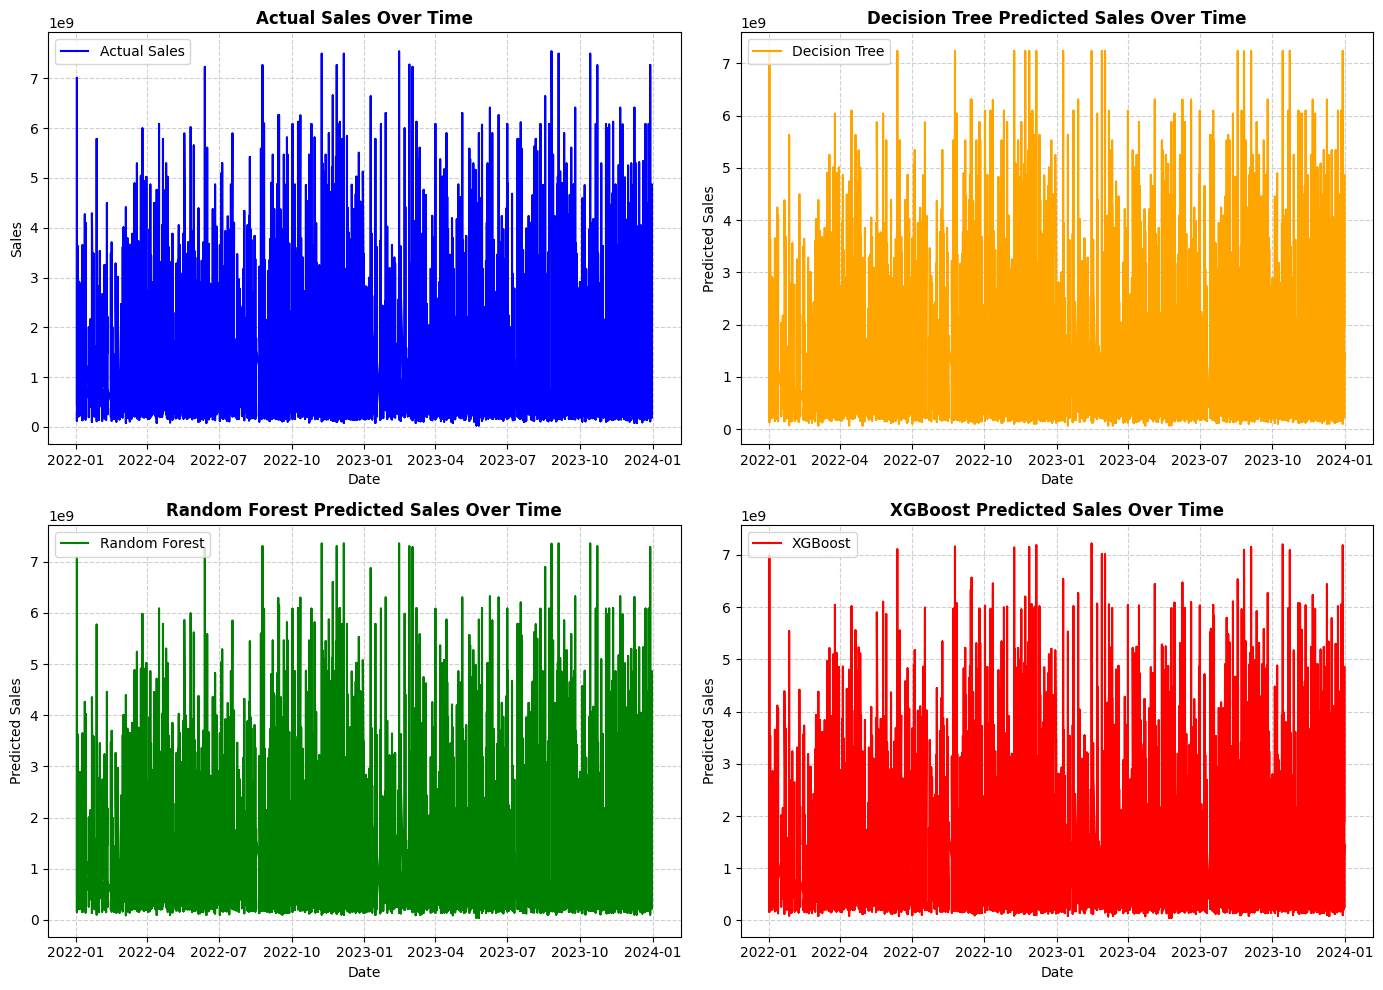

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a 2x2 grid and flatten axes array for easy unpacking
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

# 2. Plot Actual Sales
ax1.plot(df_sales_prediction['date'], df_sales_prediction['sales'], label='Actual Sales', color='blue')
ax1.set_title('Actual Sales Over Time', fontsize=12, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# 3. Plot Decision Tree Predictions
ax2.plot(df_sales_prediction['date'], df_sales_prediction['Decision Tree_predicted_revenue'], label='Decision Tree', color='orange')
ax2.set_title('Decision Tree Predicted Sales Over Time', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Predicted Sales')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# 4. Plot Random Forest Predictions
ax3.plot(df_sales_prediction['date'], df_sales_prediction['Random Forest_predicted_revenue'], label='Random Forest', color='green')
ax3.set_title('Random Forest Predicted Sales Over Time', fontsize=12, fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Predicted Sales')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.6)

# 5. Plot XGBoost Predictions
ax4.plot(df_sales_prediction['date'], df_sales_prediction['XGBoost_predicted_revenue'], label='XGBoost', color='red')
ax4.set_title('XGBoost Predicted Sales Over Time', fontsize=12, fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Predicted Sales')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
df_business

,car_id,date,day,month,year,customer_name,gender,dealer_name,company,model,engine,transmission,color,dealer_no_,body_style,phone,dealer_region,price,income_customer,quantity,discount,gross_sales,discount_amount,sales,cost,total_cost,profit,profit_margin,day_of_week,is_weekend,is_workday,season,quarter,week_of_year,price_band,discount_level,weekend_discount,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,rolling_max_7
0,C_CND_000001,2022-01-02,2,1,2022,Geraldine,Male,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,06457-3834,SUV,8264678,Middletown,"467,740,000.00","242,865,000.00",1,0.05,"467,740,000.00","23,387,000.00","444,353,000.00","347,588,502.33","347,588,502.33","96,764,497.67",21.78,6,1,0,Winter,1,52,Mid,Low,0.05,"1,015,046,013.79","1,015,158,424.38","1,014,950,454.26","1,015,110,555.50","762,101,743.48","2,398,374,840.96"
1,C_CND_000002,2022-01-02,2,1,2022,Gia,Male,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,60504-7114,SUV,6848189,Aurora,"341,810,000.00","26,625,200,000.00",5,0.10,"1,709,050,000.00","170,905,000.00","1,538,145,000.00","281,435,978.53","1,407,179,892.65","130,965,107.35",8.51,6,1,0,Winter,1,52,Economy,Medium,0.10,"444,353,000.00","1,015,158,424.38","1,014,950,454.26","1,015,110,555.50","762,101,743.48","2,398,374,840.96"
2,C_CND_000003,2022-01-02,2,1,2022,Gianna,Male,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,38701-8047,Passenger,7298798,Greenville,"566,685,000.00","18,619,650,000.00",2,0.02,"1,133,370,000.00","22,667,400.00","1,110,702,600.00","433,036,322.96","866,072,645.92","244,629,954.08",22.02,6,1,0,Winter,1,52,Premium,Low,0.02,"1,538,145,000.00","1,015,158,424.38","1,014,950,454.26","1,015,110,555.50","762,101,743.48","2,398,374,840.96"
3,C_CND_000004,2022-01-02,2,1,2022,Giselle,Male,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,99301-3882,SUV,6257557,Pasco,"251,860,000.00","242,865,000.00",1,0.50,"251,860,000.00","125,930,000.00","125,930,000.00","190,288,699.80","190,288,699.80","-64,358,699.80",-51.11,6,1,0,Winter,1,52,Budget,Extreme,0.50,"1,110,702,600.00","1,015,158,424.38","1,014,950,454.26","1,015,110,555.50","762,101,743.48","2,398,374,840.96"
4,C_CND_000005,2022-01-02,2,1,2022,Grace,Male,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,53546-9427,Hatchback,7081483,Janesville,"440,755,000.00","26,355,350,000.00",4,0.10,"1,763,020,000.00","176,302,000.00","1,586,718,000.00","371,011,737.64","1,484,046,950.56","102,671,049.44",6.47,6,1,0,Winter,1,52,Mid,Medium,0.10,"125,930,000.00","1,015,158,424.38","1,014,950,454.26","1,015,110,555.50","762,101,743.48","2,398,374,840.96"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23900,C_CND_023902,2023-12-31,31,12,2023,Martin,Male,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,60504-7114,Passenger,8583598,Pasco,"215,880,000.00","242,865,000.00",2,0.50,"431,760,000.00","215,880,000.00","215,880,000.00","159,542,978.96","319,085,957.92","-103,205,957.92",-47.81,6,1,0,Winter,4,52,Budget,Extreme,0.50,"324,719,500.00","1,473,381,000.00","1,480,936,800.00","1,347,990,700.00","1,459,854,108.36","4,301,768,800.00"
23901,C_CND_023903,2023-12-31,31,12,2023,Jimmy,Female,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,06457-3834,Hardtop,7914229,Middletown,"287,840,000.00","16,191,000,000.00",5,0.25,"1,439,200,000.00","359,800,000.00","1,079,400,000.00","202,866,442.05","1,014,332,210.25","65,067,789.75",6.03,6,1,0,Winter,4,52,Budget,Extreme,0.25,"215,880,000.00","4,301,768,800.00","1,128,332,800.00","887,652,300.00","664,705,437.10","2,168,514,600.00"
23902,C_CND_023904,2023-12-31,31,12,2023,Emma,Male,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,99301-3882,Sedan,7659127,Scottsdale,"377,790,000.00","12,682,950,000.00",1,0.50,"377,790,000.00","188,89

In [ ]:
df_business['company']

0             Ford
1            Dodge
2         Cadillac
3           Toyota
4            Acura
           ...    
23900     Plymouth
23901    Chevrolet
23902          BMW
23903    Chevrolet
23904        Lexus
Name: company, Length: 23905, dtype: object

## Save models

In [ ]:
from pathlib import Path
#import joblib
#import json

#BASE_DIR = Path.cwd().parent / "models"
#MODEL_DIR = BASE_DIR / "sales_prediction"

folders = [
    "models",
    "metrics",
    "parameters",
    "scalers",
    "encoders",
    "feature_importance"
]

for folder in folders:
    (MODEL_DIR / folder).mkdir(parents=True, exist_ok=True)

NameError: name 'MODEL_DIR' is not defined

In [ ]:
for model_name, model in trained_models.items():
    filename = model_name.lower().replace(" ", "_")

    if model_name == "CatBoost":
        model.save_model(MODEL_DIR / "models" / f"{filename}.cbm")
    elif model_name == "XGBoost":
        model.save_model(MODEL_DIR / "models" / f"{filename}.json")
    else:
        joblib.dump(model, MODEL_DIR / "models" / f"{filename}.pkl")

print("\nAll models have been saved successfully.")


All models have been saved successfully.


## Save scalers

In [ ]:
joblib.dump(feature_scaler, MODEL_DIR / "scalers" / "feature_scaler.pkl")
joblib.dump(target_scaler, MODEL_DIR / "scalers" / "target_scaler.pkl")

print("\nFeature and target scalers have been saved successfully.")


Feature and target scalers have been saved successfully.


## Save encoders

In [ ]:
joblib.dump(
    encoders,
    MODEL_DIR /
    "encoders" /
    "label_encoders.pkl"
)

print("Encoders saved.")

Encoders saved.


## Save metrics

In [ ]:
df_model_summary.to_csv(MODEL_DIR / "metrics" / "model_metrics.csv", index=False)
df_comparison.to_csv(MODEL_DIR / "metrics" / "model_comparison.csv", index=False)

print("\nModel metrics and comparison have been saved successfully.")


Model metrics and comparison have been saved successfully.


## Save feature importance

In [ ]:
# Save feature importance to csv
for model_name, importance in feature_importances.items():
    clean_name = model_name.lower().replace(" ", "_")
    importance.to_csv(MODEL_DIR / "feature_importance" / f"{clean_name}_feature_importance.csv", index=False)

## Save feature names

In [ ]:
with open(MODEL_DIR / "parameters" / "feature_columns.json", "w") as f:
    json.dump(X.columns.tolist(), f, indent=4)

print("\nFeature columns have been saved successfully.")


Feature columns have been saved successfully.
